# Dataset Preparation and Model Utilities

This notebook contains reference codes: 
utilities for preparing datasets and evaluating models.

# Count Files in Directory
(assuming tranl/val/test split is done)


from here, please make sure the data path is changed to yours


In [ ]:
output_dir = '/data/Paired pOCT Dataset/low-res'  #YOUR PATH

files = [f for f in os.listdir(output_dir) if os.path.isfile(os.path.join(output_dir, f))]

print(f'Number of files in the folder: {len(files)}')

# Evaluate Image Quality Metrics

PSNR, SSIM, and LPIPS metrics for ground truth, input and output images. Computed in batches.

In [ ]:
## !pip install lpips
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import torch
import lpips
from torchvision import transforms
from PIL import Image


gt_folder = '/data/ground_truth'
input_folder = '/data/condition'
output_folder = '/data/1000'

loss_fn = lpips.LPIPS(net='alex').cuda()  # initialize LPIPS model (use .cuda() if using GPU)

def preprocess_lpips(img_np):
    if len(img_np.shape) == 2: 
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    img_tensor = torch.from_numpy(img_np.astype(np.float32) / 255.0).permute(2, 0, 1)
    img_tensor = (img_tensor - 0.5) * 2   # normalize to [-1,1]
    return img_tensor.unsqueeze(0).cuda()


ssim_input_list, psnr_input_list = [], []
ssim_output_list, psnr_output_list = [], []
lpips_input_list, lpips_output_list = [], []

outliers = []
results = []

for gt_file in os.listdir(gt_folder):
    if gt_file.endswith('.png') and 'original' in gt_file:
        gt_path = os.path.join(gt_folder, gt_file)
        input_path = os.path.join(input_folder, gt_file)
        output_path = os.path.join(output_folder, gt_file)

        gt_img = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
        input_img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        output_img = cv2.imread(output_path, cv2.IMREAD_GRAYSCALE)

        # SSIM/PSNR
        psnr_input_val = psnr(gt_img, input_img)
        ssim_input_val = ssim(gt_img, input_img, data_range=gt_img.max() - gt_img.min())
        psnr_output_val = psnr(gt_img, output_img)
        ssim_output_val = ssim(gt_img, output_img, data_range=gt_img.max() - gt_img.min())

        ssim_input_list.append(ssim_input_val)
        psnr_input_list.append(psnr_input_val)
        ssim_output_list.append(ssim_output_val)
        psnr_output_list.append(psnr_output_val)

        # LPIPS
        gt_tensor = preprocess_lpips(gt_img)
        input_tensor = preprocess_lpips(input_img)
        output_tensor = preprocess_lpips(output_img)

        lpips_input_val = loss_fn(gt_tensor, input_tensor).item()
        lpips_output_val = loss_fn(gt_tensor, output_tensor).item()
        lpips_input_list.append(lpips_input_val)
        lpips_output_list.append(lpips_output_val)

        results.append((gt_file, psnr_input_val, ssim_input_val, lpips_input_val,
                                   psnr_output_val, ssim_output_val, lpips_output_val))

        if ssim_output_val < 0.7:
            outliers.append((gt_file, ssim_output_val))


for r in results:
    print(f'Image: {r[0]}')
    print(f'GT vs Input  -> PSNR: {r[1]:.4f}, SSIM: {r[2]:.4f}, LPIPS: {r[3]:.4f}')
    print(f'GT vs Output -> PSNR: {r[4]:.4f}, SSIM: {r[5]:.4f}, LPIPS: {r[6]:.4f}\n')


print(f'Average PSNR for GT vs Input:  {np.mean(psnr_input_list):.4f}')
print(f'Average SSIM for GT vs Input:  {np.mean(ssim_input_list):.4f}')
print(f'Average LPIPS for GT vs Input: {np.mean(lpips_input_list):.4f}')

print(f'Average PSNR for GT vs Output: {np.mean(psnr_output_list):.4f}')
print(f'Average SSIM for GT vs Output: {np.mean(ssim_output_list):.4f}')
print(f'Average LPIPS for GT vs Output: {np.mean(lpips_output_list):.4f}\n')

print("Outliers (SSIM < 0.7):")
for outlier in outliers:  #check outliers under certain threshold
    print(f'Image: {outlier[0]}, SSIM: {outlier[1]:.4f}')


# Crop a Single Image

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt


img_path = '/data/OD.png'  
img = Image.open(img_path)


width, height = img.size
print('width:', width)
print('height', height)
left = 580
top = 48
right = width
bottom = 930

cropped_img = img.crop((left, top, right, bottom))

plt.figure(figsize=(15, 15))
plt.imshow(cropped_img)
plt.axis('off')  
plt.show()

cropped_img.save('cropped_right_side.png')

# Compute PSNR and SSIM for a single pair

PSNR and SSIM between two images to evaluate similarity.

In [ ]:

import cv2
from skimage.metrics import structural_similarity as ssim


image1 = cv2.imread('/data/sample.png')
image2 = cv2.imread('/data/ground_truth.png')


if image1.shape != image2.shape:
    raise ValueError("Input images must have the same dimensions.")

gray_image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray_image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

psnr_value = cv2.PSNR(image1, image2)

ssim_value, _ = ssim(gray_image1, gray_image2, full=True)

print(f"PSNR: {psnr_value} dB")
print(f"SSIM: {ssim_value}")


# Convert TIFF to PNG

formatting function.

In [ ]:
import os
from PIL import Image

def convert_tiff_to_png(folder_path):
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.tiff', '.tif')):
            tiff_path = os.path.join(folder_path, filename)
            png_filename = os.path.splitext(filename)[0] + '.png'
            png_path = os.path.join(folder_path, png_filename)

            try:
                with Image.open(tiff_path) as img:
                    img.save(png_path)
                    print(f"Converted: {filename} → {png_filename}")
            except Exception as e:
                print(f"Error converting {filename}: {e}")

folder = '/data/portableOCT'
convert_tiff_to_png(folder)


# OCT Image Enhancement

This cell enhances OCT images using CLAHE, denoising, gamma correction, and contrast stretching.

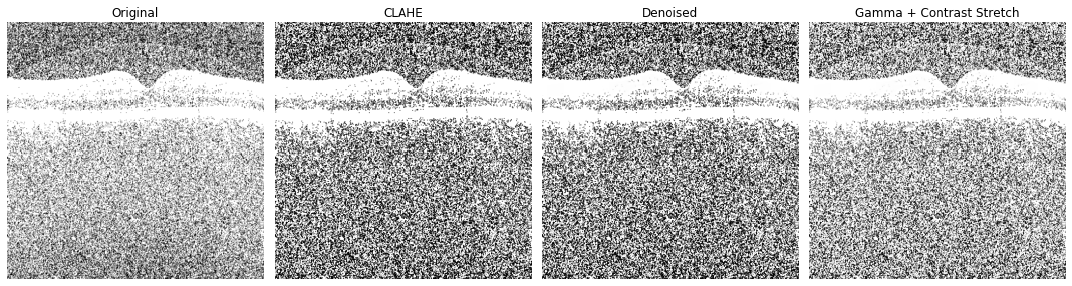

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gamma_correction(img, gamma=1.5):
    invGamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** invGamma * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

def enhance_oct_image(img_path):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

   
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) #CLAHE to enhance contrast
    img_eq = clahe.apply(img)

    img_denoised = cv2.fastNlMeansDenoising(img_eq, h=10, templateWindowSize=7, searchWindowSize=21) #average filter to reduce noise

    img_gamma = gamma_correction(img_denoised, gamma=1.5) #gamma correction to enhance bright structures and suppress background

    img_stretched = cv2.normalize(img_gamma, None, 0, 255, cv2.NORM_MINMAX) # contrast stretching to enhance white layer intensity


    plt.figure(figsize=(15, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(img_eq, cmap='gray')
    plt.title('CLAHE')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(img_denoised, cmap='gray')
    plt.title('Denoised')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(img_stretched, cmap='gray')
    plt.title('Gamma + Contrast Stretch')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


image_path = '/data/p40_OD_V.png'  #CHANGE TO YOUR IMAGE PATH
enhance_oct_image(image_path)


# Optional: ONNX Export

 exporting the model to ONNX format (quantization)

In [ ]:


def load_model_from_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        self.net.load_state_dict(checkpoint['model_state_dict'])
        self.net.to(self.config.training.device[0])  # Move to the correct device
        self.net.eval()  # Set the model to evaluation mode
        print(f"Model loaded from {checkpoint_path}")

def export_to_onnx(self, onnx_path):
        # Assuming the model is already in eval mode and loaded
        dummy_input = torch.randn(1, 3, 256, 256).to(self.config.training.device[0])  # Example dummy input (adjust shape as necessary)
        
        torch.onnx.export(self.net, 
                          dummy_input, 
                          onnx_path, 
                          input_names=['input'], 
                          output_names=['output'], 
                          dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},  # Allow dynamic batch sizes
                          opset_version=11)  # You can adjust the opset version if needed

